In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# 1. Đọc dữ liệu huấn luyện 
df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]


df_test = pd.read_csv('retail_test_20.csv') 

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Số lượng mẫu để Train: {X_train.shape[0]}")
print(f"Số lượng mẫu để Test: {X_test.shape[0]}")

Số lượng mẫu để Train: 96000
Số lượng mẫu để Test: 24000


In [ ]:
# Khởi tạo mô hình 
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Huấn luyện mô hình bằng toàn bộ dữ liệu từ file train 
dt_model.fit(X_train, y_train)

print("Quá trình huấn luyện mô hình Decision Tree đã hoàn tất!")

Quá trình huấn luyện mô hình Decision Tree đã hoàn tất!


In [10]:
# Dự đoán trên tập dữ liệu Test 
y_pred = dt_model.predict(X_test)

# 1. MAE: Sai số tuyệt đối trung bình
mae = mean_absolute_error(y_test, y_pred)

# 2. MSE: Trung bình bình phương sai số
mse = mean_squared_error(y_test, y_pred)

# 3. RMSE: Căn bậc hai của MSE
rmse = np.sqrt(mse)


print(" KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ")
print(f"1. Mean Absolute Error (MAE): {mae:.4f}")
print(f"2. Mean Squared Error (MSE): {mse:.4f}")
print(f"3. Root Mean Squared Error (RMSE): {rmse:.4f}")


 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST 
1. Mean Absolute Error (MAE): 0.4316
2. Mean Squared Error (MSE): 0.2432
3. Root Mean Squared Error (RMSE): 0.4932


In [ ]:
# phân tích chuỗi thời gian

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc lại dữ liệu gốc từ file CSV để phân tích chuỗi thời gian
df_time = pd.read_csv('retail_train_80.csv')

# 2. Khôi phục lại cột ngày tháng từ 3 cột năm, tháng, ngày có sẵn trong file 
df_time['Date'] = pd.to_datetime({
    'year': df_time['transaction_year'],
    'month': df_time['transaction_month'],
    'day': df_time['transaction_day']
})

# 3. Gom nhóm để xem tổng doanh số (sau khi giải phóng log bằng hàm expm1) theo từng tháng
df_time['real_sales'] = np.expm1(df_time['sales_amount_log'])
monthly_sales = df_time.groupby('transaction_month')['real_sales'].sum().reset_index()

Số lượng mẫu để Train: 96000
Số lượng mẫu để Test: 24000
------------------------------------------------------------


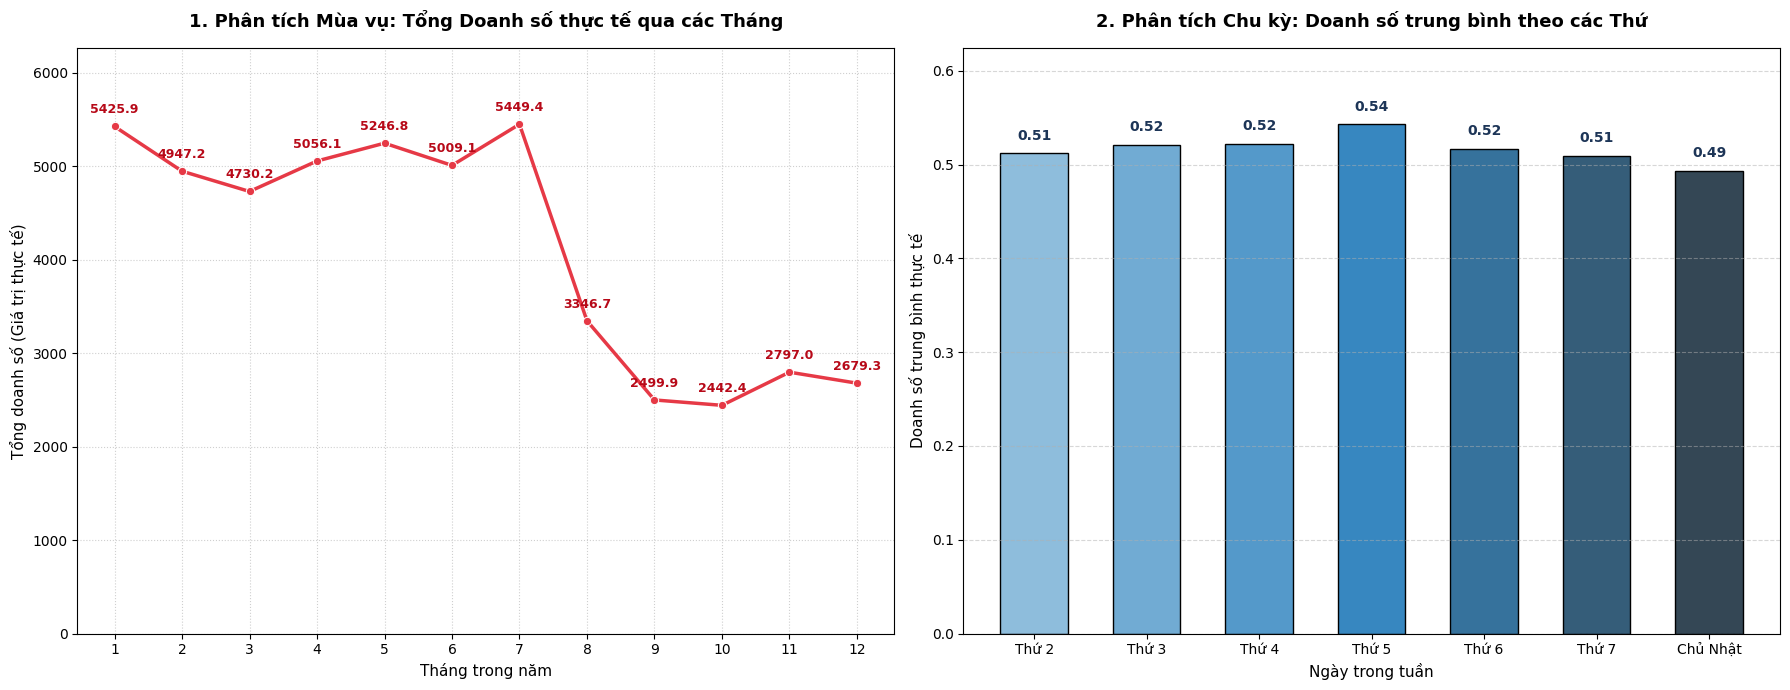

In [ ]:
# đọc dữ liệu và phân tích chuỗi thời gian
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu huấn luyện và kiểm thử 
df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

df_test = pd.read_csv('retail_test_20.csv')
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Số lượng mẫu để Train: {X_train.shape[0]}")
print(f"Số lượng mẫu để Test: {X_test.shape[0]}")
print("-" * 60)

# 2. Quy đổi Doanh số từ Log về giá trị thực tế: Doanh số = exp(sales_amount_log) - 1
df_train['real_sales'] = np.expm1(df_train['sales_amount_log'])

# Gom nhóm tính tổng doanh số theo Tháng và doanh số trung bình theo Thứ trong tuần
monthly_sales = df_train.groupby('transaction_month')['real_sales'].sum().reset_index()
weekday_sales = df_train.groupby('transaction_dayofweek')['real_sales'].mean().reset_index()

# 3. Khởi tạo khung vẽ lớn
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# ĐỒ THỊ 1: Xu hướng doanh số qua các Tháng 
sns.lineplot(data=monthly_sales, x='transaction_month', y='real_sales', marker='o', color='#e63946', linewidth=2.5, ax=axes[0])

# Vòng lặp chèn chú thích số liệu (Data Labels) vào từng nút điểm của đồ thị đường
for i, row in monthly_sales.iterrows():
    axes[0].text(row['transaction_month'], row['real_sales'] + (monthly_sales['real_sales'].max() * 0.02), 
                 f"{row['real_sales']:.1f}", 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#b70918')

axes[0].set_title('1. Phân tích Mùa vụ: Tổng Doanh số thực tế qua các Tháng', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Tháng trong năm', fontsize=11)
axes[0].set_ylabel('Tổng doanh số (Giá trị thực tế)', fontsize=11)
axes[0].set_xticks(range(1, 13)) 
axes[0].set_ylim(0, monthly_sales['real_sales'].max() * 1.15) # Nới rộng trần đồ thị để không đè chữ
axes[0].grid(True, linestyle=':', alpha=0.6)



# ĐỒ THỊ 2: Ngày nào trong tuần bán chạy nhất 

weekday_names = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
bars = axes[1].bar(weekday_sales['transaction_dayofweek'], weekday_sales['real_sales'], color=sns.color_palette('Blues_d', 7), edgecolor='black', width=0.6)

# Vòng lặp có số liệu lên đỉnh của từng cột hình chữ nhật
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + (weekday_sales['real_sales'].max() * 0.02),
                 f"{height:.2f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1d3557')

axes[1].set_title('2. Phân tích Chu kỳ: Doanh số trung bình theo các Thứ', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Ngày trong tuần', fontsize=11)
axes[1].set_ylabel('Doanh số trung bình thực tế', fontsize=11)
axes[1].set_xticks(range(0, 7))
axes[1].set_xticklabels(weekday_names)
axes[1].set_ylim(0, weekday_sales['real_sales'].max() * 1.15) # Nới rộng trần đồ thị để không đè chữ
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.show()